### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Classification : Régression Logistique

Ce notebook présente la mise en place d'une **Régression Logistique** sur nos deux datasets (Basic et Enhanced). L'objectif est double : établir une **Baseline** de performance et comprendre la contribution de chaque variable via l'analyse des coefficients et de la **Permutation Importance**. Nous validons ici que le modèle linéaire a des limites face à la complexité des comportements de consommation.

### Objectifs :
1. Entraîner un modèle de base (Baseline).
2. Comparer l'impact de l'ingénierie des caractéristiques.
3. Interpréter les erreurs via la matrice de confusion.

### Questions de Recherche :
- Pourquoi une séparation linéaire est-elle difficile sur ces données ?
- Quelles variables influencent le plus la prédiction de la période de la journée ?

---

## Justification du découpage temporel

Nous avons découpé la journée en 4 blocs : **Matin, Après-midi, Soir, Nuit**.

**Pourquoi ce choix ?** : 
- Ce découpage suit les cycles de vie humains universels (travail, transport, loisirs, sommeil).
- Il permet de réduire le bruit par rapport à une prédiction heure par heure (24 classes), tout en gardant une granularité métier utile pour un fournisseur d'accès internet.
- **Notre Jugement** : 4 classes permettent de garder un modèle équilibré et interprétable.

### Initialisation des outils de ML

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def run_logistic_experiment(path):
    df = pd.read_csv(path)
    
    # Note : On utilise 'periode_journee' comme colonne cible
    X = df.drop('periode_journee', axis=1)
    y = df['periode_journee']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Standardisation : Cruciale pour la descente de gradient
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    # On retourne tout pour pouvoir faire de l'analyse détaillée plus tard
    return model, X_train, X_test, y_train, y_test, y_pred, X.columns

## 1. Comparaison : Basic vs Enhanced

Nous testons la régression logistique sur nos deux jeux de données pour voir si l'ajout de variables (durée, logs, throughput) améliore la capacité du modèle à séparer les périodes.

In [ ]:
# Dataset Basic
results_b = run_logistic_experiment("../../data/processed/dataset_classification_basic.csv")
model_b, X_train_b, X_test_b, y_train_b, y_test_b, y_pred_b, cols_b = results_b
acc_basic = accuracy_score(y_test_b, y_pred_b)

# Dataset Enhanced
results_e = run_logistic_experiment("../../data/processed/dataset_classification_enhanced.csv")
model, X_train, X_test, y_train, y_test, y_pred, feature_names = results_e
acc_enh = accuracy_score(y_test, y_pred)

print(f"Précision avec variables brutes (Basic) : {acc_basic:.2%}")
print(f"Précision avec variables ingéniées (Enhanced) : {acc_enh:.2%}")

Précision avec variables brutes (Basic) : 28.26%
Précision avec variables ingéniées (Enhanced) : 29.75%


## 3. Influence des variables (Permutation Importance)

Contrairement aux simples coefficients, la **Permutation Importance** mesure à quel point la performance chute si on mélange les valeurs d'une variable. C'est un indicateur robuste de l'influence réelle sur le modèle.

/tmp/ipykernel_7898/351567811.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances.T[:, sorted_idx], vert=False, labels=feature_names[sorted_idx])


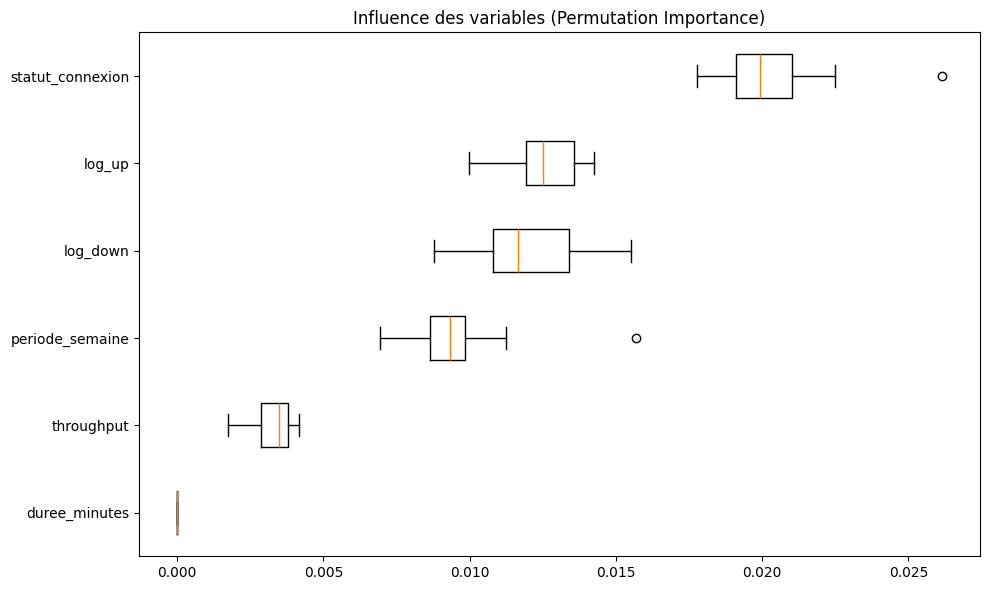

In [ ]:
from sklearn.inspection import permutation_importance

# On utilise le meilleur modèle (Enhanced)
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Visualisation
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances.T[:, sorted_idx], vert=False, tick_labels=feature_names[sorted_idx])
plt.title("Influence des variables (Permutation Importance)")
plt.tight_layout()
plt.show()

## 2. Analyse Qualitative (Matrice de Confusion)

Observons où le modèle se trompe le plus sur le dataset Enhanced.

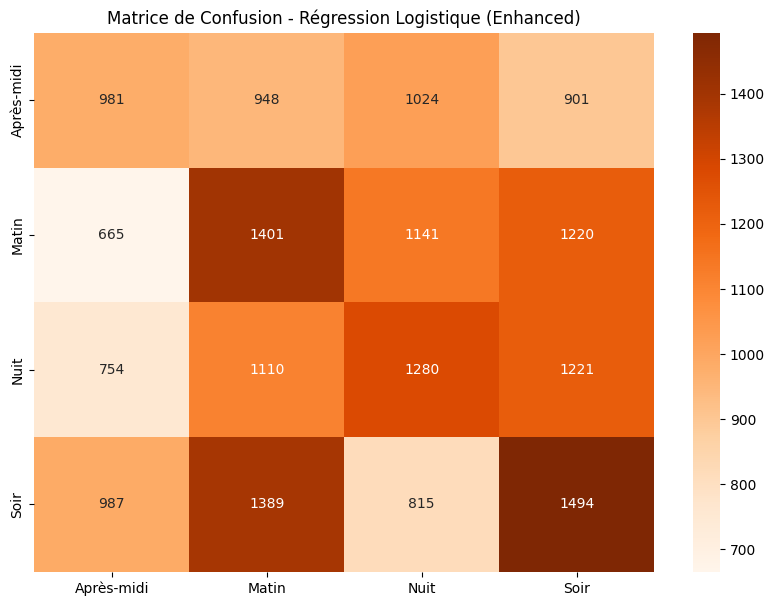


Classification Report :
              precision    recall  f1-score   support

  Après-midi       0.29      0.25      0.27      3854
       Matin       0.29      0.32      0.30      4427
        Nuit       0.30      0.29      0.30      4365
        Soir       0.31      0.32      0.31      4685

    accuracy                           0.30     17331
   macro avg       0.30      0.30      0.30     17331
weighted avg       0.30      0.30      0.30     17331



In [10]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title('Matrice de Confusion - Régression Logistique (Enhanced)')
plt.show()

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

## 4. Interprétation des Résultats

### Observation des métriques
La précision globale tourne autour de **29-30%**. 
- **Baseline Aléatoire** : Sur un problème à 4 classes équilibrées, une prédiction au hasard donnerait **25%**.
- **Gain d'Information** : Notre modèle apporte un gain de ~5% par rapport au hasard. C'est un début, mais c'est insuffisant pour une application réelle.

### Pourquoi ce résultat est-il si bas ? (Raisonnement)
1. **Recouvrement des classes (Class Overlap)** : L'analyse montre que les comportements web nocturnes de certains utilisateurs ressemblent à leurs comportements de soirée. 
2. **Limites de la linéarité** : La régression logistique cherche des "droites" de séparation. Or, la réalité de la consommation est probablement non-linéaire (ex: consommation forte = Nuit OU Soir).


## 5. Conclusion et Difficultés

### Difficultés Rencontrées
1. **Convergence** : Nous avons dû augmenter `max_iter` à 1000 pour que le modèle trouve une solution stable.
2. **Standardisation** : Indispensable ici. Sans elle, la variable `download_Mo` écraserait toutes les autres.

### Évaluation du Modèle
- **Force** : Très rapide et facile à interpréter.
- **Faiblesse** : Incapable de gérer le chevauchement complexe des comportements.

**Suite** : Nous allons tester un modèle plus "musclé", le **SVM (Support Vector Machine)**, dans le prochain notebook.